In [ ]:
import rasterio

raster_path = "../data/downloaded_data/GAEZ/Rasters_in_use/LR/ter/BC_slpmed05.tif"

with rasterio.open(raster_path) as src:
    data = src.read(1)  # first band
    profile = src.profile

print("Raster profile:", profile)
print("Unique values in raster:", set(data.flatten()))


In [ ]:
import pandas as pd

# Suppose we have a CSV mapping value -> description
legend_df = pd.read_csv("../data/downloaded_data/GAEZ/gaez_slpmed05_legend.csv")

# Make a dictionary
class_map = dict(zip(legend_df['class'], legend_df['description']))

# Apply mapping to raster values
unique_vals = set(data.flatten()) - {profile['nodata']}
for val in unique_vals:
    print(val, ":", class_map.get(val, "Unknown"))


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
import RES.visuals as vis

def plot_gaez_raster_with_boundary(raster_path, legend_csv, gdf_path,
                                   dst_crs="EPSG:4326", figsize=(12, 7),compass_length=0.1,
                                   font_family='serif',
                                   title=None):
    """
    Plot a GAEZ categorical raster with a shadowed boundary layer using colors from CSV.
    """
    plt.rcParams['font.family'] = font_family
    # Load legend and exclude class 0
    legend_df = pd.read_csv(legend_csv)
    legend_df = legend_df[legend_df['class'] != 0]
    class_map = dict(zip(legend_df['class'], legend_df['description']))
    
    # Create a ListedColormap from the CSV colors
    cmap = ListedColormap(legend_df['color'].tolist())
    
    # Load and reproject GeoDataFrame
    gdf = gpd.read_file(gdf_path)
    gdf = gdf.to_crs(dst_crs)
    
    # Open and reproject raster
    with rasterio.open(raster_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })

        data_reproj = np.empty((height, width), dtype=src.dtypes[0])

        reproject(
            source=rasterio.band(src, 1),
            destination=data_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    # Mask NoData and class 0
    nodata_val = kwargs.get("nodata", None)
    data_masked = np.ma.masked_equal(data_reproj, nodata_val) if nodata_val is not None else np.ma.masked_invalid(data_reproj)
    data_masked = np.ma.masked_equal(data_masked, 0)
    
    # Normalization
    bounds = np.arange(0.5, len(class_map) + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)
    


    fig, ax = plt.subplots(figsize=figsize)

    
    # Shadow layer (thicker light grey)
    gdf.boundary.plot(ax=ax, edgecolor='grey', linewidth=1, zorder=0)
    
    extent = (
        kwargs["transform"][2],
        kwargs["transform"][2] + kwargs["transform"][0] * kwargs["width"],
        kwargs["transform"][5] + kwargs["transform"][4] * kwargs["height"],
        kwargs["transform"][5]
    )
    
    # Plot raster
    im = ax.imshow(data_masked, cmap=cmap, norm=norm, extent=extent)
    
    # Overlay actual boundaries (thin black line)
    gdf.boundary.plot(ax=ax, edgecolor='k', linewidth=0.2)
    

    # Colorbar
    cbar = plt.colorbar(im, ticks=range(1, len(class_map) + 1), shrink=0.5)
    cbar.ax.set_yticklabels([f"{v}: {class_map.get(v, 'Unknown')}" for v in range(1, len(class_map) + 1)],
                        fontsize=10)
    
    # Remove axes
    ax.set_axis_off()
    
    # Title
    if title is None:
            ax.set_title(f"GAEZ Raster: {raster_path.split('/')[-1]}", fontsize=14, fontweight="bold", pad=15)
    
    else:ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    
    # vis.add_compass_arrow(ax,length=compass_length)
    plt.tight_layout()
    plt.show()


 └> No path provided to save the plot, saving to current working directory
 └> No path provided to save the plot, saving to current working directory
 └> No path provided to save the plot, saving to current working directory


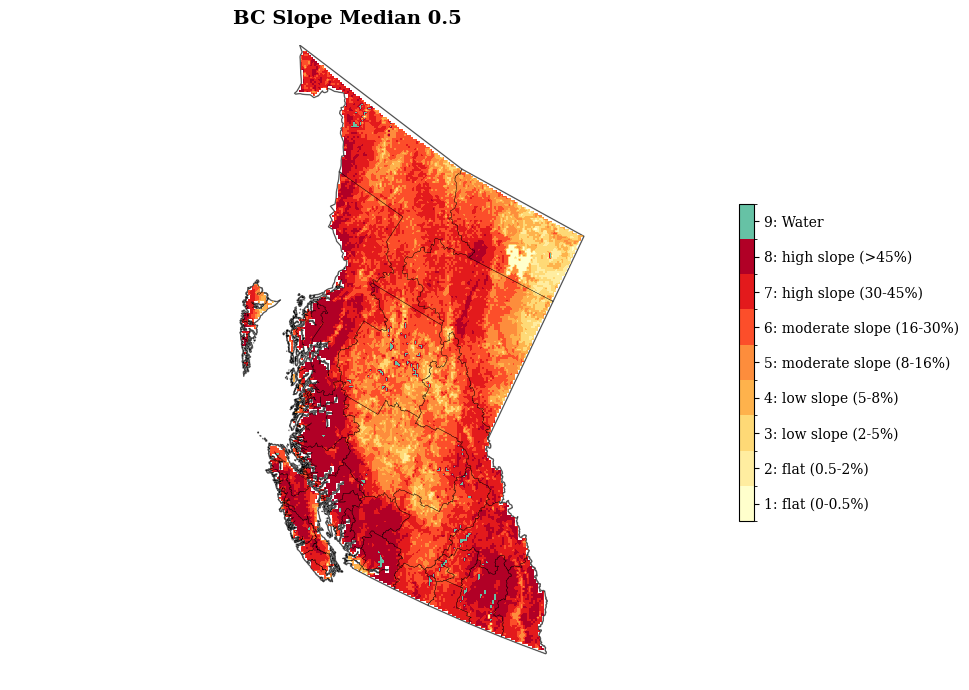

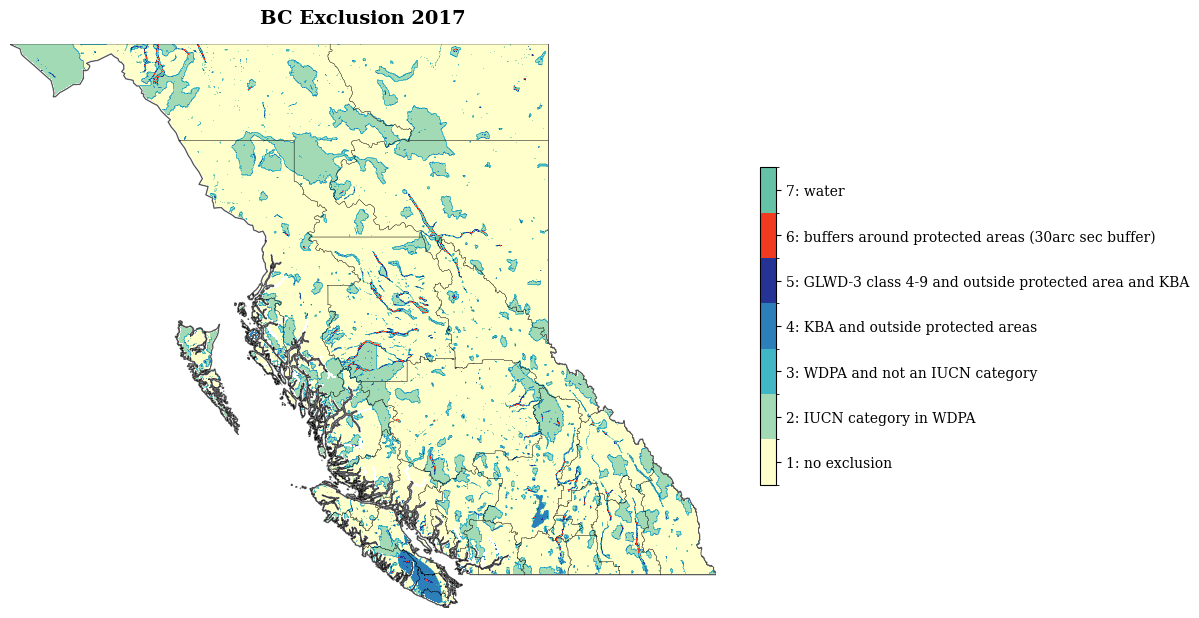

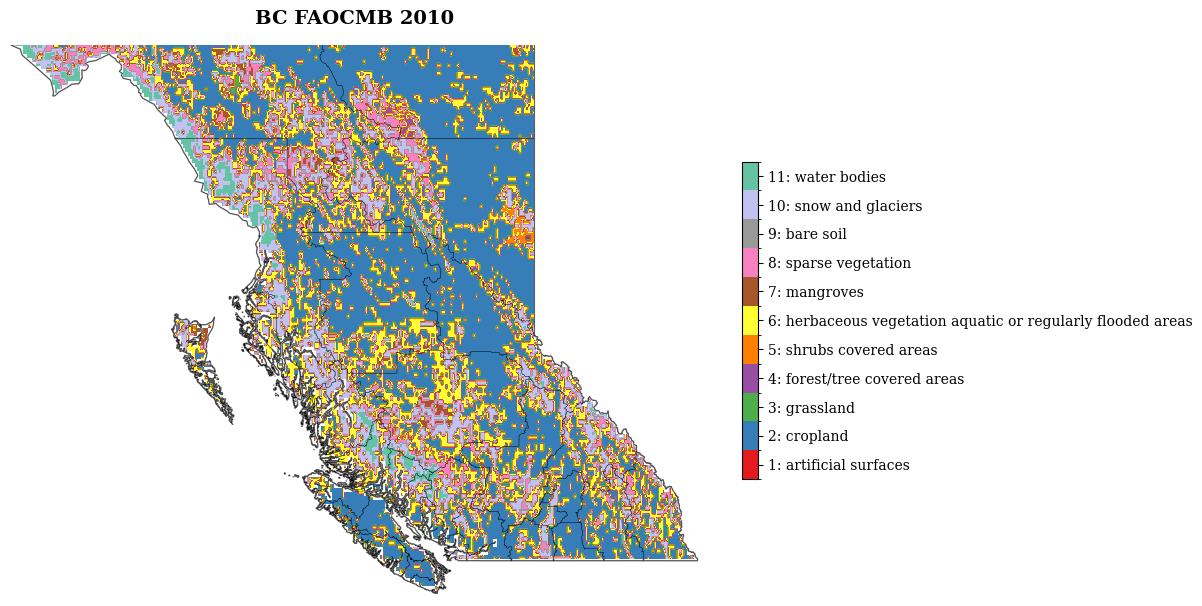

In [3]:
from RES import visuals as vis
vis.plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/ter/BC_slpmed05.tif",
    legend_csv="../data/gaez_slpmed05_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_BC.geojson",
    dst_crs="EPSG:3347",
    compass_length=0.04,
    title="BC Slope Median 0.5"
)
vis.plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/excl/BC_exclusion_2017.tif",
    legend_csv="../data/exclusion_2017_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_BC.geojson",
    dst_crs="EPSG:4326",
    compass_length=0.06,
    title="BC Exclusion 2017"
)

vis.plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/lco/BC_faocmb_2010.tif",
    legend_csv="../data/faocmb_2010_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_BC.geojson",
    dst_crs="EPSG:4326",
    compass_length=0.06,
    title="BC FAOCMB 2010"
)


In [ ]:
plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/ter/AB_slpmed05.tif",
    legend_csv="../data/gaez_slpmed05_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_AB.geojson",
    compass_length=0.04
)
plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/excl/AB_exclusion_2017.tif",
    legend_csv="../data/exclusion_2017_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_AB.geojson",
    dst_crs="EPSG:4326",
    compass_length=0.06
)

plot_gaez_raster_with_boundary(
    raster_path="../data/downloaded_data/GAEZ/Rasters_in_use/LR/lco/AB_faocmb_2010.tif",
    legend_csv="../data/faocmb_2010_legend.csv",
    gdf_path="../data/processed_data/regions/gadm41_Canada_L2_AB.geojson",
    dst_crs="EPSG:4326",
    compass_length=0.06
)


In [ ]:
import RES.RESources as RES
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
from RES.hdf5_handler import DataHandler
import RES.visuals as vis
store=f"data/store/resources_BC.h5"
datahandler=DataHandler(store)
cells=datahandler.from_store('cells')
boundary=datahandler.from_store('boundary')

# Set Required Args to Activate Modules

In [ ]:
required_args = {
            "config_file_path": 'config/config.yaml',
            "region_short_code": 'BC',
            "resource_type": 'solar'
        }

In [ ]:
from RES.power_nodes import GridNodeLocator

power_nodes = GridNodeLocator(**required_args)

lines = power_nodes.get_OSM_grid_lines()
lines_filtered = lines[~(lines['voltage'] == '400000')]
lines_filtered = lines_filtered[~(lines_filtered['voltage'] == '400')]

In [ ]:
from shapely.ops import nearest_points

def find_nearest_single_connection_point(cell_centroid, cell_geometry, cell_gdf, line_gdf):
    """
    For a given cell centroid and its geometry:
    - If any lines intersect the cell, return the nearest point on them.
    - Otherwise, find the nearest cell with intersecting lines and return the nearest point on its lines.
    Returns: (nearest_point, distance)
    """
    # 1. Lines intersecting this cell
    intersecting_lines = line_gdf[line_gdf.geometry.intersects(cell_geometry)].copy()

    if not intersecting_lines.empty:
        # Clip to the cell geometry
        intersecting_lines["geometry"] = intersecting_lines.geometry.intersection(cell_geometry)
        lines_to_search = intersecting_lines
    else:
        # 2. Find nearest neighbor with intersecting lines
        # Filter cells that have at least one intersecting line
        candidate_cells = cell_gdf[cell_gdf.geometry.apply(lambda geom: not line_gdf[line_gdf.geometry.intersects(geom)].empty)]

        # Find the closest such cell
        candidate_cells["distance"] = candidate_cells.geometry.centroid.distance(cell_centroid)
        nearest_cell = candidate_cells.loc[candidate_cells["distance"].idxmin()]

        # Get intersecting lines for that cell
        cell_geom = nearest_cell.geometry
        intersecting_lines = line_gdf[line_gdf.geometry.intersects(cell_geom)].copy()
        intersecting_lines["geometry"] = intersecting_lines.geometry.intersection(cell_geom)
        lines_to_search = intersecting_lines

    # 3. Find the nearest point on those lines
    distances = lines_to_search.geometry.apply(lambda line: cell_centroid.distance(line))
    nearest_geom = lines_to_search.loc[distances.idxmin(), "geometry"]

    nearest_point = nearest_geom.interpolate(nearest_geom.project(cell_centroid))
    distance = cell_centroid.distance(nearest_point)
    cell_gdf["has_line"] = cell_gdf.geometry.apply(
        lambda geom: not line_gdf[line_gdf.geometry.intersects(geom)].empty
    )

    return nearest_point, distance

In [ ]:
# Ensure centroid is prepared once
cells["centroid"] = cells.apply(lambda row: Point(row["x"], row["y"]), axis=1)

# Apply to each row to compute the single connection point
cells[["nearest_connection_point", "nearest_distance"]] = cells.apply(
    lambda row: find_nearest_single_connection_point(row["centroid"], row["geometry"], cells,lines),
    axis=1, result_type="expand"
)

In [ ]:
lines=gpd.read_file('data/downloaded_data/OSM/BC_power.geojson')

In [ ]:
datahandler.to_store(lines, 'lines')

In [ ]:
datahandler.show_tree(store)

In [ ]:
resource_type = 'wind'

In [ ]:
# from RES.power_nodes import GridNodeLocator

# power_nodes = GridNodeLocator(**required_args)

# lines = power_nodes.get_OSM_grid_lines()
# # lines_filtered = lines[~(lines['voltage'] == '400000')]
# # lines_filtered = lines_filtered[~(lines_filtered['voltage'] == '400')]

In [ ]:
# import geopandas as gpd
# from shapely.geometry import Point, LineString

# # Filter only LineString geometries
# lines = lines[lines.geometry.type == "LineString"].copy()
# lines = lines.set_geometry("geometry")
# lines.crs = cells.crs

# # Create centroid column once
# cells["centroid"] = cells.apply(lambda row: Point(row["x"], row["y"]), axis=1)

In [ ]:
from shapely.geometry import LineString, MultiLineString
from shapely.ops import nearest_points

def filter_lineal_geometries(geom):
    """
    Ensure the result of intersection is a LineString or MultiLineString.
    Handles GeometryCollections recursively.
    """
    if geom.is_empty:
        return None
    elif geom.geom_type in ["LineString", "MultiLineString"]:
        return geom
    elif geom.geom_type == "GeometryCollection":
        lines = [g for g in geom.geoms if g.geom_type in ["LineString", "MultiLineString"]]
        if lines:
            return lines[0] if len(lines) == 1 else MultiLineString(lines)
    return None

def find_nearest_single_connection_point(cell_centroid, cell_geometry, cell_gdf, line_gdf):
    # Keep only valid lineal geometries
    line_gdf = line_gdf[line_gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])]

    # 1. Try to find lines intersecting this cell
    intersecting_lines = line_gdf[line_gdf.geometry.intersects(cell_geometry)].copy()

    if not intersecting_lines.empty:
        # Clip to the cell geometry
        intersecting_lines["geometry"] = intersecting_lines.geometry.intersection(cell_geometry)
    else:
        # 2. Find nearest neighbor with intersecting lines
        candidate_cells = cell_gdf[cell_gdf.geometry.apply(
            lambda geom: not line_gdf[line_gdf.geometry.intersects(geom)].empty
        )].copy()

        candidate_cells["distance"] = candidate_cells.geometry.centroid.distance(cell_centroid)
        nearest_cell = candidate_cells.loc[candidate_cells["distance"].idxmin()]

        # Intersect that cell's geometry
        cell_geom = nearest_cell.geometry
        intersecting_lines = line_gdf[line_gdf.geometry.intersects(cell_geom)].copy()
        intersecting_lines["geometry"] = intersecting_lines.geometry.intersection(cell_geom)

    # 3. Clean geometries: keep only valid line geometries
    intersecting_lines["geometry"] = intersecting_lines.geometry.apply(filter_lineal_geometries)
    intersecting_lines = intersecting_lines[intersecting_lines.geometry.notnull()]

    if intersecting_lines.empty:
        return None, float("inf")  # or handle gracefully

    # 4. Find the nearest point on the lines
    distances = intersecting_lines.geometry.apply(lambda line: cell_centroid.distance(line))
    nearest_geom = intersecting_lines.loc[distances.idxmin(), "geometry"]

    nearest_point = nearest_geom.interpolate(nearest_geom.project(cell_centroid))
    distance = cell_centroid.distance(nearest_point)
    cell_gdf["has_line"] = cell_gdf.geometry.apply(
        lambda geom: not line_gdf[line_gdf.geometry.intersects(geom)].empty
    )

    return nearest_point, distance


In [ ]:
lines=lines[lines['element']=='way']
lines=lines[lines['voltage'].notna()]

In [ ]:
# Split the 'voltage' column into multiple columns
voltage_split = lines['voltage'].str.split(';', expand=True)

# Rename the columns to voltage1, voltage2, etc.
voltage_split.columns = [f'voltage{i+1}' for i in range(voltage_split.shape[1])]

# Concatenate the new columns with the original DataFrame
lines = pd.concat([lines, voltage_split], axis=1)
# Ensure the 'voltage' column exists and contains data
if 'voltage' in lines.columns and lines['voltage'].notna().any():
    # Ensure 'voltage' is treated as string before splitting
    voltage_split = lines['voltage'].astype(str).str.split(';', expand=True)

    # Convert all split values to numeric, coerce errors to NaN
    voltage_split = voltage_split.apply(pd.to_numeric, errors='coerce')

    # Assign the max voltage per row
    lines['max_voltage'] = voltage_split.max(axis=1)

    # Rename and concatenate the voltage columns
    voltage_split.columns = [f'voltage_{i+1}' for i in range(voltage_split.shape[1])]
    lines = pd.concat([lines, voltage_split], axis=1)
else:
    print("The 'voltage' column is missing or empty in the DataFrame.")


In [ ]:
lines.plot('max_voltage',legend=True)

In [ ]:
# Ensure centroid is prepared once
from shapely import Point
lines=lines[lines['max_voltage']>=11000]

cells["centroid"] = cells.apply(lambda row: Point(row["x"], row["y"]), axis=1)

# Apply to each row to compute the single connection point
cells[["nearest_connection_point", "nearest_distance"]] = cells.apply(
    lambda row: find_nearest_single_connection_point(row["centroid"], row["geometry"], cells,lines),
    axis=1, result_type="expand"
)

In [ ]:
cells["has_line"] = cells.geometry.apply(
        lambda geom: not lines[lines.geometry.intersects(geom)].empty
    )

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# Assuming 'data' and 'cells' are already loaded
data = lines

# Ensure valid geometries
cells = cells[cells.is_valid]
data = data[data.is_valid]

# Setup colormap based on voltage
unique_voltages = sorted(data['max_voltage'].dropna().unique())
cmap = cm.get_cmap('tab10', len(unique_voltages))
color_map = dict(zip(unique_voltages, cmap.colors))

# Split cells
cells_with_line = cells[cells["has_line"] == True]
cells_without_line = cells[cells["has_line"] == False]

# Plot setup
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor("white")

# Plot cells with and without lines
cells_with_line.plot(ax=ax, color="lightcoral", edgecolor="white", alpha=0.3, linewidth=0.5)
cells_without_line.plot(ax=ax, color="grey", edgecolor="white", alpha=0.2, linewidth=0.5)

# Plot nearest connection points with glow effect
# cells.set_geometry("nearest_connection_point").plot(
#     ax=ax, 
#     color='red', 
#     markersize=10, 
#     alpha=0.8, 
#     label="Within Grid Nearest line points",
#     path_effects=[pe.withStroke(linewidth=1, foreground="yellow", alpha=1)]
# )

# Plot voltage-based line data
for voltage_level in unique_voltages:
    subset = data[data['max_voltage'] == voltage_level]
    subset.plot(
        ax=ax,
        color=color_map[voltage_level],
        markersize=20,
        label=f'Line (kV): {voltage_level/1E3}',
        alpha=0.5,
        edgecolor='white',
        linewidth=2
    )

# Optional: Add basemap
# ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=1, crs=cells.crs)

# Final plot styling
ax.set_title("British Columbia", fontsize=16, fontweight='bold', pad=15)
ax.axis("off")

# Manually adding the legend for cells with and without lines
from matplotlib.lines import Line2D

# Create custom legend handles
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=10, alpha=0.6,label='Cells with Line'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=10, alpha=0.6,label='Cells without Line')
]

# Combine custom legend with other handles
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(legend_handles + list(by_label.values()), 
          ['Cells with Line', 'Cells without Line'] + list(by_label.keys()), 
          loc='upper left', bbox_to_anchor=(1.0, 1), frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
plt.savefig('Lines_BC.png',dpi=600,transparent=True)

In [ ]:
# RES_module.datahandler.to_store(RES_module.gridcells.resource_grid_cells,'cells')

In [ ]:
# RES_module.gridcells.resource_grid_cells

In [ ]:
# datahandler.from_store('cells')

In [ ]:
RES_module.gridcells.region_boundary

In [ ]:
A=RES_module.find_grid_nodes()

In [ ]:
# RES_module.build()

In [ ]:
cells=datahandler.from_store('cells')
boundary=datahandler.from_store('boundary')
solar_clusters=datahandler.from_store('clusters/solar')
wind_clusters=datahandler.from_store('clusters/wind')
solar_clusters_ts=datahandler.from_store('timeseries/clusters/solar')
wind_clusters_ts=datahandler.from_store('timeseries/clusters/wind')

In [ ]:
resource_clusters_solar,cluster_timeseries_solar=RES_module.select_top_sites(solar_clusters,
                                                                solar_clusters_ts,
                                                                    resource_max_capacity=10)

resource_clusters_wind,cluster_timeseries_solar=RES_module.select_top_sites(wind_clusters,
                                                                wind_clusters_ts,
                                                                    resource_max_capacity=20)

In [ ]:
# resource_clusters_solar.plot('potential_capacity',legend=True)
# resource_clusters_wind.plot('potential_capacity',legend=True)

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
legend_x_ax_offset=1
# Ensure 'Region' is in the columns for both boundary and cells
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)

# Assign a number to each region
boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
solar_bins = [0, 100, 200, 300, 500, float('inf')]  # Custom ranges
solar_labels = ['<100','100-200', '200-300', '300-500','>500']  # Labels for legend

# Define custom bins and labels for solar and wind capacity
wind_bins = [0, 300, 500, 1000, 2000,3000, float('inf')]  # Custom ranges
wind_labels = ['<300','300-500', '500-1000', '1000-2000','2000-3000', '>3000']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
resource_clusters_solar['solar_category'] = pd.cut(resource_clusters_solar['potential_capacity'], bins=solar_bins, labels=solar_labels, include_lowest=True)
resource_clusters_wind['wind_category'] = pd.cut(resource_clusters_wind['potential_capacity'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle("Potential Sites for Targeted Capacity Investments", fontsize=16,weight='bold')
# Set axis off for both subplots
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
shadow_offset = 0.01

# Plot solar map on ax1
# Add shadow effect for solar map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax1, color='None', edgecolor='grey', linewidth=1, alpha=0.7)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
resource_clusters_solar.plot(column='solar_category', ax=ax1, cmap='Wistia', legend=True, 
           legend_kwds={'title': "Solar Capacity (MW)", 'loc': 'upper right','bbox_to_anchor':(legend_x_ax_offset,1), 'frameon': False})

# Plot actual boundary for solar map
boundary.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.7)
"""
# Annotate region numbers for solar map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Plot wind map on ax2
# Add shadow effect for wind map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax2, color='None', edgecolor='grey', linewidth=1, alpha=0.7)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot wind cells
resource_clusters_wind.plot(column='wind_category', ax=ax2, cmap='summer', legend=True, 
           legend_kwds={'title': "Wind Capacity (MW)", 'bbox_to_anchor':(legend_x_ax_offset,1), 'frameon': False})

# Plot actual boundary for wind map
boundary.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.7)
"""
# Annotate region numbers for wind map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Adjust layout for cleaner appearance
fig.patch.set_alpha(0)  # Make figure background transparent
plt.tight_layout()

# Show the side-by-side plot

# plt.savefig('solar_wind_capacity_map.png',dpi=300)
plt.show()

In [ ]:
resource_clusters_wind.plot(column='potential_capacity',cmap='summer', legend=True,)